In [1]:
#!/usr/local/bin/python3
# import os
# os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=8'
from time import time
import argparse
from pathlib import Path
from functools import partial
from multiprocessing import Pool, set_start_method

import numpy as onp
from jax import config
import jax.numpy as np
from jax.lax import integer_pow
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
from matplotlib import colors

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
import gwfast.network as network
from gwfast.signals import AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.lensing_utils import (
    compute_lensed_angles_approx,
    convert_y_from_Einstein_to_Rorbit
)
from gwfast.fisherTools import (
    reduce_Fisher_matrix,
    compute_covariance_matrix,
    covariance_change_variable
)

/Users/yuranzhang/gwfast_AGN/gwfast_moddd/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
n_R = 3
n_y = 3
model = 'generic'

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_Lensed = network.DetNet({'H1': H1_Lensed, 'L1': L1_Lensed, 'V1': V1_Lensed})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [9]:
reference_parameters = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 0.5, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
# reference_parameters['M_lz'] = 1e6
# reference_parameters['iota'] = 0.999 * np.pi / 2
reference_parameters_1 = reference_parameters.copy()
reference_parameters_2 = reference_parameters.copy()
reference_parameters_1['Mc'] = 30
reference_parameters_2['Mc'] = 80


def Jacobian_covariance(lensing_parameters):
    # 4.b Compute the Fisher
    fisher_matrix = HLV_AGN.FisherMatr(lensing_parameters, res=100)
    # 4.c Reduce and compute covar
    covar_matrix, _ = compute_covariance_matrix(fisher_matrix, cores=1)

    from_params = ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
    transformed_cov_mat, transformed_parameters, transformed_keys = covariance_change_variable(
        covar_matrix, lensing_parameters, lensing_transform, from_params
    )
    return transformed_cov_mat, transformed_parameters, transformed_keys


def direct_covariance(lensing_parameters):
    model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)
    keys = list(model_parameters.keys()).copy()

    lensed_HLV_fisher = HLV_Lensed.FisherMatr(model_parameters, res=200)

    # If some of the events is nan, then the reduce matrix won't work
    cleaned_lensed_HLV_fisher = np.nan_to_num(lensed_HLV_fisher, nan=0.0)

    lensed_fisher_mat, rm_keys = reduce_Fisher_matrix(cleaned_lensed_HLV_fisher, keys=keys)
    print(rm_keys)
    lensed_fisher_mat[lensed_fisher_mat == 0.0] = np.nan
    lensed_cov_mats, _ = compute_covariance_matrix(lensed_fisher_mat, cores=1)
    return lensed_cov_mats, model_parameters, keys

def simple_lensing_covariance(lensing_parameters):
    model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)
    keys = list(model_parameters.keys()).copy()

    shape = model_parameters['Mc'].shape

    model_parameters['delta_iota'] = np.full(shape, 0.0)
    model_parameters['delta_phase'] = np.full(shape, 0.0)
    model_parameters['delta_psi'] = np.full(shape, 0.0)
    model_parameters['relative_mass'] = np.full(shape, 1.0)
    print(model_parameters)

    simple_HLV_fisher = HLV_Lensed.FisherMatr(model_parameters, res=200)
    # If some of the events is nan, then the reduce matrix won't work
    cleaned_simple_HLV_fisher = np.nan_to_num(simple_HLV_fisher, nan=0.0)

    simple_fisher_mat, rm_keys = reduce_Fisher_matrix(cleaned_simple_HLV_fisher, keys=keys)
    print(rm_keys)
    simple_fisher_mat[simple_fisher_mat == 0.0] = np.nan
    simple_cov_mats, _ = compute_covariance_matrix(simple_fisher_mat, cores=1)
    return simple_cov_mats, model_parameters, keys

def lensing_transform(lensing_parameters):
    # A fiducial phase which does not affect the Jacobian results
    lensing_parameters['phase'] = 0.0
    lensing_parameters['psi'] = 0.0
    outputs = compute_lensed_angles_approx(lensing_parameters)
    phenom_changes = {}
    phenom_changes['delta_iota'] = outputs['iota_m'] - outputs['iota_p']
    phenom_changes['delta_phase'] = outputs['phase_m'] - outputs['phase_p']
    phenom_changes['delta_psi'] = outputs['psi_m'] - outputs['psi_p']

    # (Radial gravitational potential is cancelled)
    relative_magification = outputs['sqrt_mu_p'] / outputs['sqrt_mu_m']
    phenom_changes['relative_distance'] = relative_magification * integer_pow((1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p']), 2)
    phenom_changes['relative_mass'] = (1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p'])
    phenom_changes['delta_time'] = outputs['delta_time']

    return phenom_changes

def reorder_covariance(cov, keys, desired_order):
    idx = [keys.index(k) for k in desired_order]
    idx_arr = np.array(idx, dtype=np.int32)
    # reorder rows then columns using jax.numpy.take
    cov_reordered = np.take(np.take(cov.astype(np.float64), idx_arr, axis=0), idx_arr, axis=1)
    new_keys = [keys[i] for i in idx]
    return cov_reordered, new_keys

def reorder_params_dict(params_dict, desired_order):
    return {k: np.array(params_dict[k]) for k in desired_order}

def get_bayes_factor(full_cov, full_params_dict, orig_keys, params_order, prior_widths):
    """Savage-Dickey density ratio: B_10 = p(psi_0|M1) / p(psi_0|d,M1)."""
    full_cov, _ = reorder_covariance(full_cov, orig_keys, params_order)
    full_params_dict = reorder_params_dict(full_params_dict, params_order)

    n_extra = prior_widths.shape[0]

    # Offset of fiducial values from null hypothesis (rm=1, di=dp=dps=0)
    offset = np.array([
        full_params_dict['relative_mass'] - 1.0,
        full_params_dict['delta_iota'],
        full_params_dict['delta_phase'],
        full_params_dict['delta_psi'],
    ])

    full_cov = np.moveaxis(full_cov, -1, 0)   # (n, D, D)
    offset = np.moveaxis(offset, -1, 0)        # (n, k)

    # Marginal posterior covariance of the extra parameters
    extra_cov = full_cov[:, -n_extra:, -n_extra:]  # (n, k, k)

    extra_cov_inv = np.linalg.inv(extra_cov)
    chi2 = np.einsum('...i,...ij,...j->...', offset, extra_cov_inv, offset)
    log_det_extra = np.linalg.slogdet(extra_cov)[1]

    log_posterior_at_null = (
        -0.5 * n_extra * np.log(2 * np.pi)
        - 0.5 * log_det_extra
        - 0.5 * chi2
    )
    log_prior_at_null = -np.sum(np.log(prior_widths))

    # B_10 = prior / posterior  (full model favoured when B_10 > 1)
    log_B = log_prior_at_null - log_posterior_at_null
    return log_B, chi2



def worker(Ry_tuple_sublist, model='agn', loop=2, actual_snr=False):
    '''
    Performance comment (2025/08/21)
    * Looping is recommended, but one loop is sufficient to bring the
        fractional difference between SNR and target SNR to below 1e-3
    * Computing the actual SNR at the end is not needed. The typical fractional
        error between the actual SNR and the one obtained from scaling is
        of order 1e-5 (or less).
    '''
    input_len = Ry_tuple_sublist.shape[0]
    shape = (input_len)
    lensing_parameters_1 = {key: np.full(shape, val).astype(np.float64) for key, val in reference_parameters_1.items()}
    lensing_parameters_1['R_orbit'] = Ry_tuple_sublist[:, 0]
    lensing_parameters_1['src_pos'] = Ry_tuple_sublist[:, 1]

    lensing_parameters_2 = {key: np.full(shape, val).astype(np.float64) for key, val in reference_parameters_2.items()}
    lensing_parameters_2['R_orbit'] = Ry_tuple_sublist[:, 0]
    lensing_parameters_2['src_pos'] = Ry_tuple_sublist[:, 1]

    if model == 'agn':
        covar_func = Jacobian_covariance
        network = HLV_AGN
    elif model == 'generic':
        covar_func = direct_covariance
        network = HLV_Lensed
    covariance_mat_1, params_dict_1, keys = covar_func(lensing_parameters_1)
    covariance_mat_2, params_dict_2, _ = covar_func(lensing_parameters_2)

    order = [
        'Mc', 'eta', 'iota', 'phase', 
        'chi1z', 'chi2z', 'tcoal',
        'dL', 'psi', 'theta', 'phi',
        'delta_time', 'relative_distance', 'relative_mass', 'delta_iota', 'delta_phase', 'delta_psi'
    ]

    relative_mass_prior_width = 1.0
    delta_iota_prior_width = 0.5
    delta_phase_prior_width = 0.5
    delta_psi_prior_width = 0.5
    prior_widths = np.array([relative_mass_prior_width, delta_iota_prior_width, delta_phase_prior_width, delta_psi_prior_width])

    log_B_1, chi2_1 = get_bayes_factor(covariance_mat_1, params_dict_1, keys, order, prior_widths)
    log_B_2, chi2_2 = get_bayes_factor(covariance_mat_2, params_dict_2, keys, order, prior_widths)

    target_B = 10
    log_target_B = np.log(target_B)

    def compute_scale(log_B, chi2):
        # s² = SNR_target² / SNR_ref², derived from log_B(s) ≈ log_B + 0.5*(s²-1)*χ²
        s2 = 1.0 + 2.0 * (log_target_B - log_B) / chi2
        s2 = np.maximum(s2, 1e-4)
        return 1.0 / np.sqrt(s2)

    scale_1 = compute_scale(log_B_1, chi2_1)
    scale_2 = compute_scale(log_B_2, chi2_2)
    # key_variable = 'M_lz'
    # key_idx = keys.index(key_variable)
    # std = onp.sqrt(covariance_mat[key_idx, key_idx], dtype='float64')
    # mean = params_dict['M_lz']
    # std /= mean
    # target_std = np.abs((mean - 0))/ 5
    # scale = std / target_std

    if model == 'agn':
        orig_snr_1 = network.SNR(lensing_parameters_1, res=1000)
        orig_snr_2 = network.SNR(lensing_parameters_2, res=1000)
    elif model == 'generic':
        orig_snr_1 = network.SNR(params_dict_1, res=1000)
        orig_snr_2 = network.SNR(params_dict_2, res=1000)
    result_snr_1 = orig_snr_1 / scale_1
    result_snr_2 = orig_snr_2 / scale_2

    if loop:
        def snr_loop(old_parameters, scale, target_lnB):
            new_parameters = old_parameters.copy()
            new_parameters['dL'] *= scale
            new_covariance_mat, new_params_dict, keys = covar_func(new_parameters)
            new_log_B, new_chi2 = get_bayes_factor(new_covariance_mat, new_params_dict, keys, order, prior_widths)
            new_scale = compute_scale(new_log_B, new_chi2)
            return new_scale, new_parameters

        looped = 0
        while looped < loop:
            scale_1, lensing_parameters_1 = snr_loop(lensing_parameters_1, scale_1, target_B)
            scale_2, lensing_parameters_2 = snr_loop(lensing_parameters_2, scale_2, target_B)
            frac_1 = 1 - scale_1
            frac_2 = 1 - scale_2
            looped += 1
            frac_1 = frac_1[~np.isnan(frac_1)]
            frac_2 = frac_2[~np.isnan(frac_2)]
            print(f'Loop {looped:d} v.s. target: {np.mean(frac_1):.6f} and {np.mean(frac_2):.6f}, std: {np.std(frac_1):.8f} and {np.std(frac_2):.8f}')

        _result_snr_1 = orig_snr_1 / lensing_parameters_1['dL'] * reference_parameters_1['dL']
        _result_snr_2 = orig_snr_2 / lensing_parameters_2['dL'] * reference_parameters_2['dL']
        print('(After - Before) loop', _result_snr_1 - result_snr_1, _result_snr_2 - result_snr_2)

        if actual_snr:
            if model == 'agn':
                computed_snr_1 = network.SNR(lensing_parameters_1, res=1000)
                computed_snr_2 = network.SNR(lensing_parameters_2, res=1000)
            elif model == 'generic':
                computed_snr_1 = network.SNR(params_dict_1, res=1000)
                computed_snr_2 = network.SNR(params_dict_2, res=1000)
            print('Actual v.s. Scaling (1 - Scaling/Actual):', 1 - computed_snr_1 / _result_snr_1, 1 - computed_snr_2 / _result_snr_2)
            return computed_snr_1, computed_snr_2
        else:
            return _result_snr_1, _result_snr_2

In [10]:
tic = time()
# 1. Prepare matrix of (y, R)
y_Eins_array = np.linspace(0.01, 2, n_y)  # in Einstein radii
R_orbit_array = np.geomspace(10, 5000, n_R)
R_orbit_mesh, y_Eins_mesh = np.meshgrid(R_orbit_array, y_Eins_array, indexing='xy')
y_Rorbit_mesh = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_mesh)
Ry_tuple_list = np.vstack([R_orbit_mesh.flatten(), y_Rorbit_mesh.flatten()]).T

# Custom settings go here
results = worker(Ry_tuple_list, model=model, loop=1, actual_snr=False)

Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.
['R_orbit', 'src_pos', 'M_lz']
Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.
['R_orbit', 'src_pos', 'M_lz']
Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.
['R_orbit', 'src_pos', 'M_lz']
Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.
['R_orbit', 'src_pos', 'M_lz']
Loop 1 v.s. target: -0.810379 and -0.718521, std: 0.66335543 and 0.11289772
(After - Before) loop [nan nan nan  0.  0. nan  0.  0. nan] [nan nan nan  0.  0. nan  0. nan nan]


In [11]:
results_1, results_2 = results[0], results[1]
# results_1 = list(results_1)
# results_2 = list(results_2)

print('Elapsed Time (min):', (time() - tic) / 60)

# concat_result_1 = np.concatenate(results_1, axis=0)
# concat_result_2 = np.concatenate(results_2, axis=0)
# snr_grid_1 = concat_result_1.reshape((n_y, n_R))
# snr_grid_2 = concat_result_2.reshape((n_y, n_R))
snr_grid_1 = results_1.reshape((n_y, n_R))
snr_grid_2 = results_2.reshape((n_y, n_R))

Elapsed Time (min): 8.60038156112035


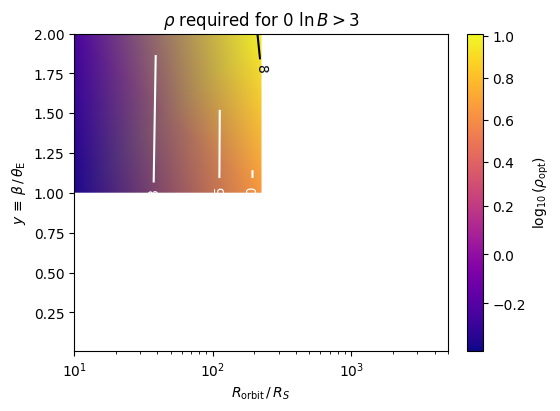

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 4), constrained_layout=True)
# Color plot for 1 of 2 datasets
log10_snr = np.log10(snr_grid_1)
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')
nans = np.isnan(log10_snr)
centre = np.mean(log10_snr[~nans])
# Make the whole thing 5% larger
_min, _max = np.min(log10_snr[~nans]), np.max(log10_snr[~nans])
midpoint = (_max + _min) / 2
half_range = (_max - _min) / 2 * 1.05
norm = colors.TwoSlopeNorm(vmin=midpoint - half_range, vcenter=centre, vmax=midpoint + half_range)
im = ax.pcolormesh(R_orbit_array, y_Eins_array, log10_snr, cmap=cmap, norm=norm, shading='gouraud')
# Contour lines for both datasets
for snr_grid, color in zip([snr_grid_1, snr_grid_2], ['black', 'white']):
    log10_snr = np.log10(snr_grid)
    cont_snrs = [8, 15, 30, 50, 100]
    cont = ax.contour(R_orbit_array, y_Eins_array, log10_snr, colors=[color], levels=onp.log10(cont_snrs))
    labels = {lvl: f'{snr:d}' for lvl, snr in zip(cont.levels, cont_snrs)}
    ax.clabel(cont, fmt=labels, fontsize=10)
ax.tick_params(which='both', direction='out')
ax.set_xscale('log')
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_{\rm E}$')
ax.set_title(r'$\rho$ required for 0 $\ln B>3$')
# ax.set_title(r'$\rho$ required for 0 to lie outside the $5\sigma$ region of $p(M_{Lz})$')
fig.colorbar(im, ax=ax, label=r'$\log_{10}(\rho_{\rm opt})$')
